<a href="https://colab.research.google.com/github/annna-martynova/sales-analysis/blob/main/Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####This project focused on store sales analysis and sales performance evaluation. The analysis included estimating sales distribution across different sales channels to identify the most effective sources of revenue. It also covered margin analysis by product categories and countries to understand profitability and regional performance. In addition, an ABC analysis was conducted to classify products based on their contribution to total sales and overall business value, helping support better business and inventory decisions.


In [ ]:
pip install abc-analysis

In [ ]:
#import of all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from abc_analysis import abc_analysis

In [ ]:
#conecting to Google Drive
from google.colab import drive
drive.mount ("/content/drive/")
%cd /content/drive/MyDrive/Mate_homework

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content/drive/MyDrive/Mate_homework


In [ ]:
#creating a new df with events table
events_df = pd.read_csv("events.csv", parse_dates = True)
events_df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.00,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,"1,993.00",205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,"4,693.00",668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,"1,171.00",109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,"7,648.00",47.45,31.79


In [ ]:
#checking general information about events_df
events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


Order ID - order number \
Order Date - date when order was made \
Ship Date - date of shipping \
Order Priority - priority of order \
Country Code - unique 3-letter country code \
Product ID - unique product number \
Sales Channel - channels of sales \
Unit Cost - price of unit cost

In [ ]:
events_df[['Units Sold', 'Unit Price', 'Unit Cost']].describe()

,Units Sold,Unit Price,Unit Cost
count,"1,328.00","1,330.00","1,330.00"
mean,"4,952.20",264.89,187.25
std,"2,905.20",217.32,176.16
min,2.00,9.33,6.92
25%,"2,356.75",81.73,35.84
50%,"4,962.00",154.06,97.44
75%,"7,459.50",437.20,263.33
max,"9,999.00",668.27,524.96


A high std value may indicate that the price range is very spread out across all indicators. Also, a big difference between average and median values in Unite Price and Unit Cost colums show us that there is very heterogeneous and the mini and max prices have a large difference

In [ ]:
#findind a precent of mising values from total
events_df.isnull().sum()/len(events_df) * 100

,0
Order ID,0.00
Order Date,0.00
Ship Date,0.00
Order Priority,0.00
Country Code,6.17
Product ID,0.00
Sales Channel,0.00
Units Sold,0.15
Unit Price,0.00
Unit Cost,0.00


In [ ]:
#droping minor missing values in events_df
events_df.dropna(subset="Units Sold", inplace= True)
print(events_df['Units Sold'].isnull().sum()) #checking if all missing values were deleted
events_df['Country Code'].fillna("Unknown", inplace= True)
print(events_df['Country Code'].isnull().sum()) #checking if all missing values were replaced

0
0


/tmp/ipykernel_5456/853556557.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





I dropped some rows where units sold were missing. Because percent of missing values are very small, so it would not affect on our final analysis.\
Also, I replaced mising values in country_code with "Unknown". Because percent of mising values are quit high in tjat column. So if I drop all rows that have missing value in that column, it will significantly affect and distort our final analysis.

In [ ]:
#changing name of columns for a snake_case
events_df.rename(columns={
    "Order ID": "order_id",
    "Order Date": "order_date",
    "Ship Date": "ship_date",
    "Order Priority": "order_priority",
    "Country Code": "country_code",
    "Product ID": "product_id",
    "Sales Channel": "sales_channel",
    "Units Sold": "units_sold",
    "Unit Price": "unit_price",
    "Unit Cost": "unit_cost"
}, inplace= True)
events_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        1328 non-null   int64  
 1   order_date      1328 non-null   object 
 2   ship_date       1328 non-null   object 
 3   order_priority  1328 non-null   object 
 4   country_code    1328 non-null   object 
 5   product_id      1328 non-null   int64  
 6   sales_channel   1328 non-null   object 
 7   units_sold      1328 non-null   float64
 8   unit_price      1328 non-null   float64
 9   unit_cost       1328 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 114.1+ KB


In [ ]:
events_df['sales_channel'] = events_df['sales_channel'].str.lower()
events_df['sales_channel'].value_counts()

,count
sales_channel,
offline,665
online,663


In [ ]:
#deleting all possible spaces in a string value
events_df['order_priority'].str.strip()
events_df['country_code'].str.strip()
events_df['sales_channel'].str.strip()

,sales_channel
0,online
1,offline
2,online
3,online
4,offline
...,...
1325,online
1326,offline
1327,offline
1328,online


In [ ]:
#checking if there is any duplicates in events_df
events_df.duplicated().sum()

np.int64(0)

In [ ]:
#creating a new df with products table
products_df = pd.read_csv("products.csv")
products_df

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies
5,4594,Fruits
6,5988,Vegetables
7,7331,Baby Food
8,8875,Meat
9,8293,Cosmetics


In [ ]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
#checking if there is any duplicates in products_df
products_df.duplicated().sum()

np.int64(0)

We can see that this table has only 2 colums. \
id - id of product\
item_type - name of category

In the future we can use id from products_df and product_id from events_df as key to join this two tables together.

In [ ]:
#creating third df with countries table
countries_df = pd.read_csv("countries.csv")
countries_df.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
countries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
#searching for missing numbers
countries_df.isnull().sum()

,0
name,0
alpha-2,1
alpha-3,0
region,1
sub-region,1


In [ ]:
#rewriting name of columns using snake_case
countries_df.rename(columns={
    "name": "country_name",
    "alpha-2": "alpha_2",
    "alpha-3": "alpha_3",
    "sub-region": "sub_region"
}, inplace= True)
countries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_name  249 non-null    object
 1   alpha_2       248 non-null    object
 2   alpha_3       249 non-null    object
 3   region        248 non-null    object
 4   sub_region    248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
#replacing name of one country so Python will see this name corectly
countries_df.loc[countries_df['country_name'] == "Namibia", "alpha_2"] = "NM"
countries_df.loc[countries_df['country_name'] == "Antarctica", "region"] = "Antarctica"
countries_df.loc[countries_df['country_name'] == "Antarctica", "sub_region"] = "Antarctica"

Countries df has next columns:\
name - full name of country,\
alpha_2 - short name of country with 2 letters\
alpha_3 = short name of country with 3 letters\
region - geographycal region where this country located\
sub_region - more specific location of country inside the region\

We can see that countries_df has alpha_3 column with a name of country written with 3 letters. And in events_df we have column country_code that has the same way of way writing name of country. In the future we will use this columns as keys to join this two df together.



In [ ]:
#Joining all 3 df together and creating of final df that we will analyse
sales_df = events_df.merge(products_df, left_on="product_id", right_on="id", how="left").merge(countries_df, left_on="country_code", right_on="alpha_3", how="left")
sales_df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,country_name,alpha_2,alpha_3,region,sub_region
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,online,650.00,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,offline,"1,993.00",205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,101025998,7/18/2014,8/11/2014,M,Unknown,7940,online,"4,693.00",668.27,502.54,7940,Household,NaN,NaN,NaN,NaN,NaN
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,online,"1,171.00",109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,offline,"7,648.00",47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe


In [ ]:
#droping all unnecessary columns
sales_df.drop(columns=['id', 'alpha_2', 'alpha_3'], inplace= True)
#making sure that all columns were droped correctly
sales_df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country_name,region,sub_region
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,online,650.00,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,offline,"1,993.00",205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,7/18/2014,8/11/2014,M,Unknown,7940,online,"4,693.00",668.27,502.54,Household,NaN,NaN,NaN
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,online,"1,171.00",109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,offline,"7,648.00",47.45,31.79,Beverages,Serbia,Europe,Southern Europe


I dropped these columns because they were unnecessary and some of them were repeating twice in our final df

In [ ]:
#making sure that python see our dates columns as date, not a string
sales_df['order_date'] = pd.to_datetime(sales_df['order_date'])
sales_df['ship_date'] = pd.to_datetime(sales_df['ship_date'])


In [ ]:
#addinng new columns with necessarliy information
days_diff = sales_df['ship_date'] - sales_df['order_date'] #counting day diff

sales_df['delivery_time'] = days_diff.dt.days #turning this day diff into int value that show us delivery time in days
sales_df['delivery_time'].head()

,delivery_time
0,10
1,0
2,24
3,31
4,38


In [ ]:
#adding order weekday, month, year so I can see weekly and montly sales distribution
sales_df['order_weekday'] = sales_df['order_date'].dt.day_name()
sales_df['order_month'] = sales_df['order_date'].dt.month_name()
sales_df['order_year'] = sales_df['order_date'].dt.year
sales_df[['order_weekday','order_month', 'order_year']].head()

,order_weekday,order_month,order_year
0,Wednesday,October,2014
1,Thursday,August,2016
2,Friday,July,2014
3,Saturday,May,2017
4,Saturday,August,2012


In [ ]:
#adding columns with revenue and profit
sales_df['revenue'] = sales_df['unit_price'] * sales_df['units_sold']
sales_df['cost'] = sales_df['unit_cost'] * sales_df['units_sold']
sales_df['profit'] = sales_df['revenue'] - sales_df['cost']
sales_df['profit_margin'] = sales_df['profit']/sales_df['revenue'] * 100
sales_df[['revenue', 'cost', 'profit', 'profit_margin']].head()

,revenue,cost,profit,profit_margin
0,"133,705.00","76,121.50","57,583.50",43.07
1,"409,960.10","233,400.23","176,559.87",43.07
2,"3,136,191.11","2,358,420.22","777,770.89",24.80
3,"127,966.88","41,968.64","85,998.24",67.20
4,"362,897.60","243,129.92","119,767.68",33.00


##**Now I will do some basic analysis to get key metrics**

In [ ]:
total_order = sales_df['order_id'].nunique()
total_customers_countries = sales_df['country_name'].nunique()
total_revenue = sales_df['revenue'].sum()
total_profit = sales_df['profit'].sum()
total_profit_margin = (sales_df['profit'].sum() / sales_df['revenue'].sum()) * 100
avg_order_value = sales_df['revenue'].mean()
avg_delivery_time = sales_df['delivery_time'].mean()

print(f"""
Total Orders: {total_order}
Total Сustomer Сountries: {total_customers_countries}
Total Revenue: {total_revenue:,.2f}$
Total Profit: {total_profit:,.2f}$
Overall Profit Margin: {total_profit_margin.round(1)}%
Avg Order Value: {avg_order_value:,.2f}$
Avg Delivery Time: {avg_delivery_time.round(0).astype(int)} days
""")



Total Orders: 1328
Total Сustomer Сountries: 45
Total Revenue: 1,702,129,408.21$
Total Profit: 501,434,459.00$
Overall Profit Margin: 29.5%
Avg Order Value: 1,281,723.95$
Avg Delivery Time: 25 days



After counting all key metrics we can see next information: \
Overall profit margin is 29.5% \
It means that company has a great pricing policy and they are being profitable.\
Average order value is high. It shows us that most orders are large. So we can conclude that the company mostly works with wholesale orders or the price of one product is very high. \
In total company has orders from 45 different countries




##Analysing Sales Channel

In [ ]:
#calculate the percentage of sales through various channels
distribution_of_sales_channel = pd.pivot_table(sales_df, values="order_id", index="sales_channel", aggfunc="count").reset_index()
revenue_by_sales_channel = pd.pivot_table(sales_df, values= "revenue", index= "sales_channel", aggfunc="sum").reset_index()
revenue_by_sales_channel

,sales_channel,revenue
0,offline,"871,760,623.88"
1,online,"830,368,784.33"


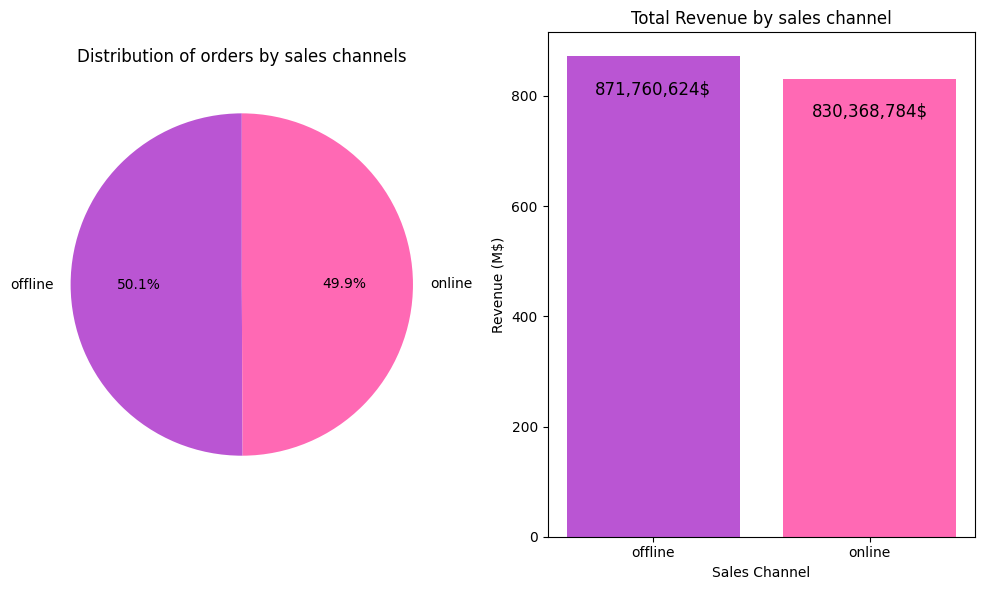

In [ ]:
#building charts to visualize information by sales_channel

fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].pie(distribution_of_sales_channel['order_id'],
          labels= distribution_of_sales_channel["sales_channel"],
          autopct = "%1.1f%%",
          startangle=90, colors =["mediumorchid", 'hotpink'])
ax[0].set_title("Distribution of orders by sales channels")

bars = ax[1].bar(revenue_by_sales_channel['sales_channel'],
          revenue_by_sales_channel['revenue'],
          color =["mediumorchid", 'hotpink'] )
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1_000_000:,.0f}'))
ax[1].set_title("Total Revenue by sales channel")
ax[1].set_xlabel("Sales Channel")
ax[1].set_ylabel("Revenue (M$)")

for bar in bars:
  plt.text(
      bar.get_x() + bar.get_width()/2,
      bar.get_height() * 0.95,
      f"{bar.get_height():,.0f}$",
      ha="center",
      va="top",
      color="black",
      fontsize=12,
  )

plt.tight_layout()
plt.show()

The analysis reveals a nearly equal distribution of orders and revenue across both sales channels, with offline accounting for a slightly higher share. This balance suggests that the company maintains a strong physical presence in all operating markets, while simultaneously sustaining a well-developed online infrastructure. The parity in revenue generation indicates that both channels are effectively optimized, reflecting stable and diversified customer relationships across all regions.

##Analysing metrics by categories

In [ ]:
category_analysis = sales_df.groupby("item_type").agg(
    avg_revenue = ('revenue', 'mean'),
    total_revenue = ('revenue', 'sum'),
    avg_profit = ('profit', 'mean'),
    avg_margin = ('profit_margin', 'mean'),
    total_orders = ('order_id', 'nunique'),
).sort_values(by="item_type", ascending= False).reset_index().round(2)

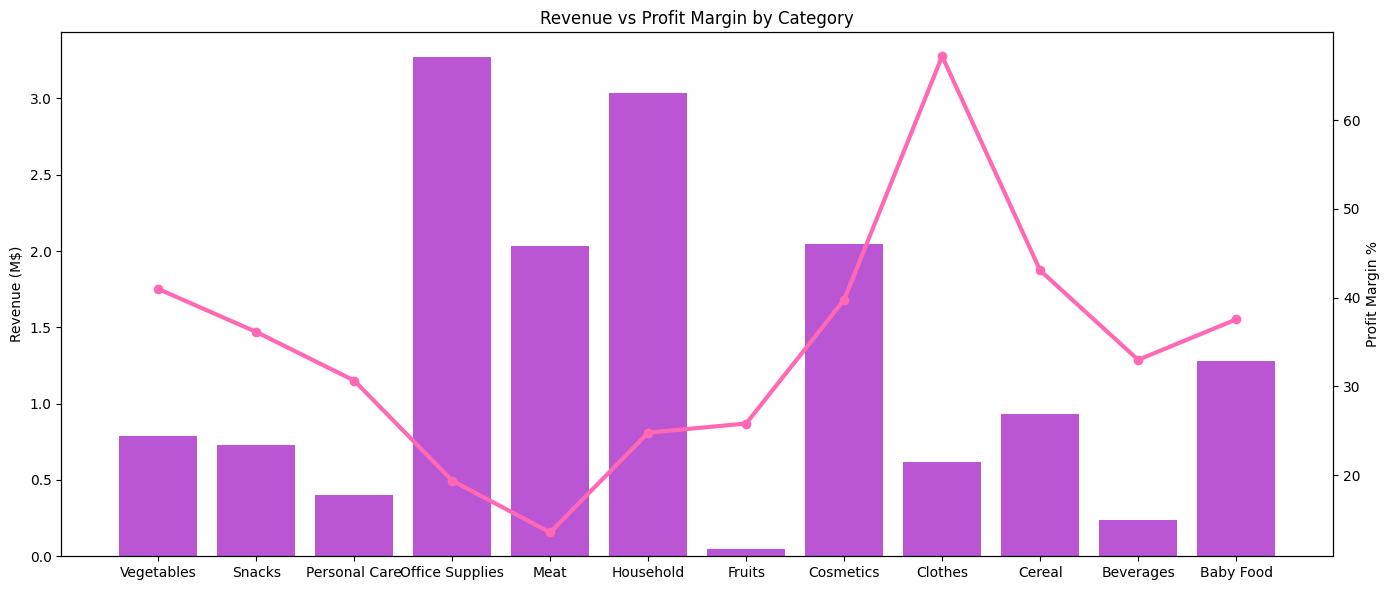

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart - Revenue
ax1.bar(category_analysis['item_type'],
        category_analysis['avg_revenue']/1_000_000,
        color='mediumorchid', label='Revenue (M$)')
ax1.set_ylabel('Revenue (M$)')

# Line chart - Profit Margin
ax2 = ax1.twinx()
ax2.plot(category_analysis['item_type'],
         category_analysis['avg_margin'],
         color='hotpink', marker='o', linewidth=3, label='Avg Margin %')
ax2.set_ylabel('Profit Margin %')

plt.title('Revenue vs Profit Margin by Category')
plt.tight_layout()
plt.show()

On the graph, we can see the values ​​of average revenue and average margin. We see the following picture, categories such as Personal Care, Fruits, and Beverages have a margin of 30%, which is a good indicator. Categories Baby Food, Cereal, Cosmetic, Snacks, and Vegetables have a margin of 50%. And the Clothing category has a margin of almost 100%. At the same time, all these categories have a very low or average income indicator. This may indicate that these categories of goods have a very low price of the product or demand for them. The company should pay a little more attention to these categories. \
At the same time, companies with high revenues have very low margin indicators. This may indicate a high cost of production, which reduces the possibility of a high markup for them, or inefficient pricing. The company should review prices in these categories

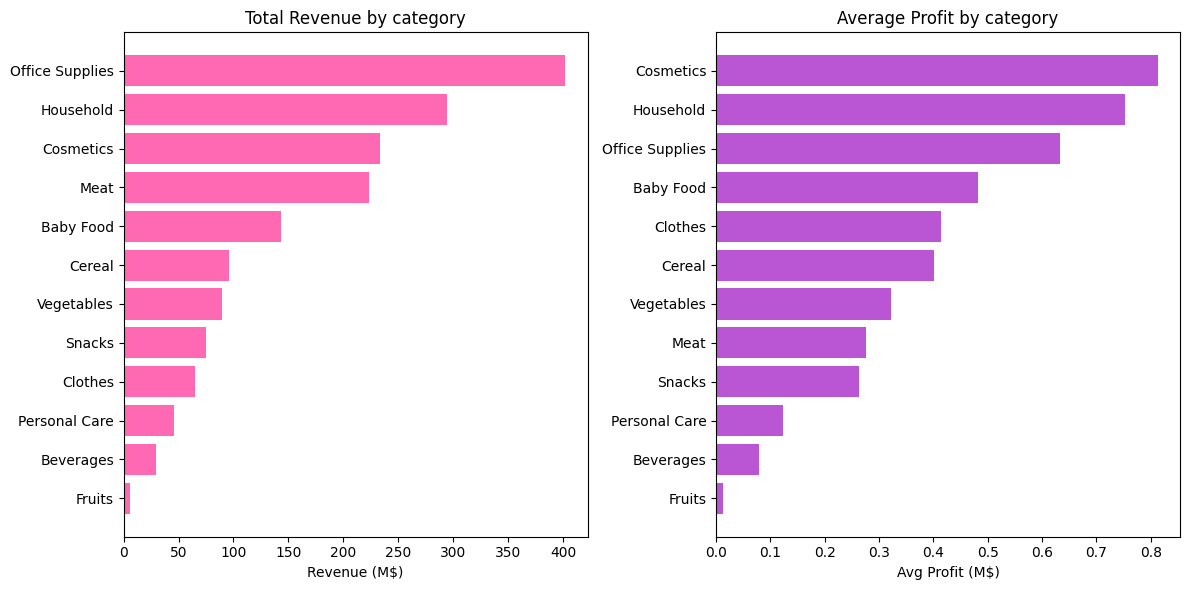

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].barh(category_analysis.sort_values('total_revenue')['item_type'],
             category_analysis.sort_values('total_revenue')['total_revenue']/1_000_000 ,
             color = 'hotpink')
ax[0].set_title("Total Revenue by category")
ax[0].set_xlabel("Revenue (M$)")

ax[1].barh(category_analysis.sort_values('avg_profit')['item_type'],
             category_analysis.sort_values('avg_profit')['avg_profit']/1_000_000 ,
             color = 'mediumorchid')
ax[1].set_title("Average Profit by category")
ax[1].set_xlabel("Avg Profit (M$)")

plt.tight_layout()
plt.show()

Overall, we see that the top 3 categories in terms of revenue and profit remain the same. Only their order changes. The Cosmetics category is in third place in terms of revenue, but in first place in terms of profit. This may be due to a lower cost of goods and a higher percentage of added value per unit of goods.

In [ ]:
#doing ABC analysis to use this information in future visualization
abc = abc_analysis(sales_df['revenue'])
a_index = abc['Aind']
b_index = abc['Bind']
c_index = abc['Cind']

cond_list = [sales_df.index.isin(a_index),
             sales_df.index.isin(b_index),
             sales_df.index.isin(c_index)]

choice_list = ['A', 'B', 'C']
sales_df['abc'] = np.select(cond_list, choice_list, default='C')
sales_df['abc'].head()

,abc
0,C
1,C
2,A
3,C
4,C


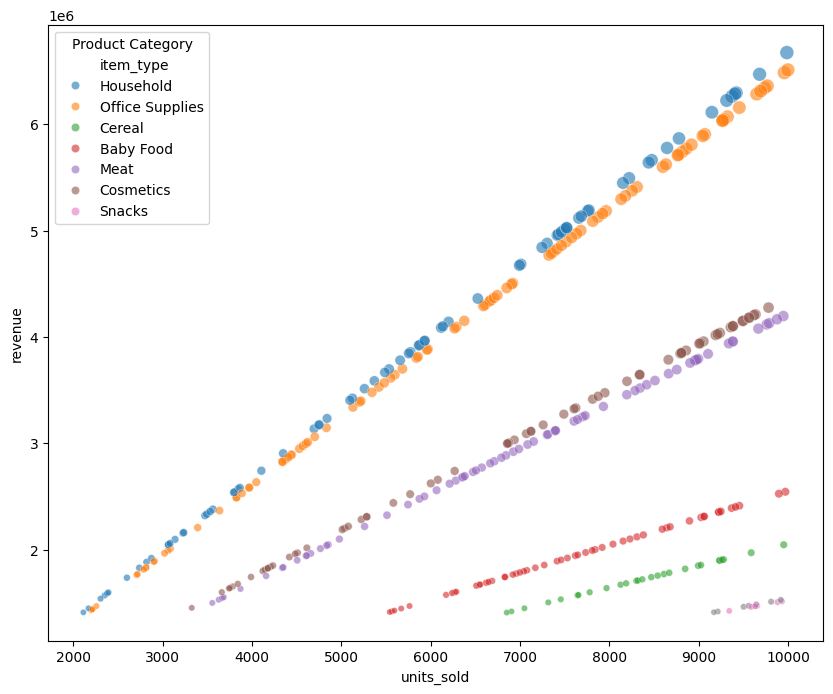

In [ ]:
#building histogram for A-categories products
A_categories = sales_df[sales_df['abc'] == 'A']

plt.figure(figsize=(10,8))
ax = sns.scatterplot(data = A_categories, x = 'units_sold', y='revenue', hue='item_type', size='revenue', sizes=(20, 100), alpha = 0.6)

handles, labels = ax.get_legend_handles_labels()

n_categories = A_categories['item_type'].nunique()

ax.legend(handles[:n_categories],
               labels[:n_categories],
               title='Product Category')

plt.show()

This histogram clearly shows the direct dependence of revenue on the number of goods sold. In categories such as Household and Office Supplies, this growth is more rapid. This is due to the fact that the cost of one unit of goods is high in these categories. While the growth in the Snacks category is almost horizontal. This shows us that with an increase in sales in this category, our income almost does not increase

##Analysing metrics by countries and regions

In [ ]:
total_orders_by_country = pd.pivot_table(sales_df, values="units_sold", index="country_name", aggfunc= "sum").reset_index()
total_orders_by_country['units_sold'] = total_orders_by_country['units_sold'].astype(int)
total_orders_by_country.head()

,country_name,units_sold
0,Albania,90608
1,Andorra,185686
2,Armenia,150665
3,Austria,145573
4,Belarus,153432


In [ ]:
import plotly.io as pio
pio.renderers.default = 'colab'

In [ ]:
#building a map to see disrtibution of units sold around the world
map = px.choropleth(total_orders_by_country,
              locations="country_name",
              locationmode="country names",
              color = "units_sold",
              title="Units Sold by Country",
              color_continuous_scale="Plasma")
map.update_layout(title_x=0.5)
map.show()

After evaluating the map of the distribution of units sold around the world, we can conclude that the company mainly concentrates its work in Europe

In [ ]:
#lookinf for top-5 countrie by revenue
top_5_countries_by_revenue = sales_df.groupby('country_name')['revenue'].sum().sort_values(ascending=False).reset_index().head()
top_5_countries_by_revenue

,country_name,revenue
0,Czech Republic,"53,543,932.14"
1,Ukraine,"53,252,317.54"
2,Bosnia and Herzegovina,"50,117,508.49"
3,Macedonia,"49,222,085.25"
4,San Marino,"47,883,708.48"


Text(0.5, 0, 'Revenue (M$)')

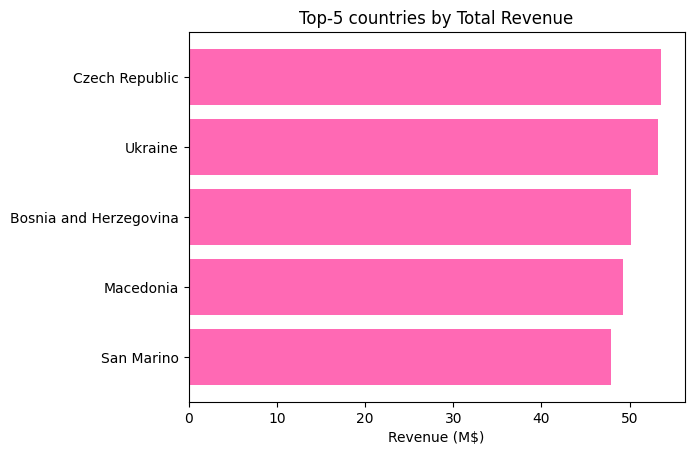

In [ ]:
top_5_sorted = top_5_countries_by_revenue.sort_values('revenue', ascending=True)
plt.barh(top_5_sorted['country_name'], top_5_sorted['revenue']/1_000_000, color='hotpink')
plt.title("Top-5 countries by Total Revenue")
plt.xlabel("Revenue (M$)")

Analyzing the top 5 countries by revenue, we can see that most of the countries on this list are somehow part of Eastern Europe. But San Marino's figures are very different from the general values. Below, I checked the number of orders in each category to understand whether any one specific category prevails in San Marino, but no such pattern was found

In [ ]:
sales_df['item_type'][sales_df['country_name'] == "San Marino"].value_counts()

,count
item_type,
Personal Care,5
Vegetables,5
Office Supplies,4
Cereal,4
Meat,3
Clothes,3
Cosmetics,3
Snacks,3
Baby Food,3


##Analysis of delivery time and weekly/monthly seasonality

Text(0.5, 1.0, 'Total count of units sold by weekday')

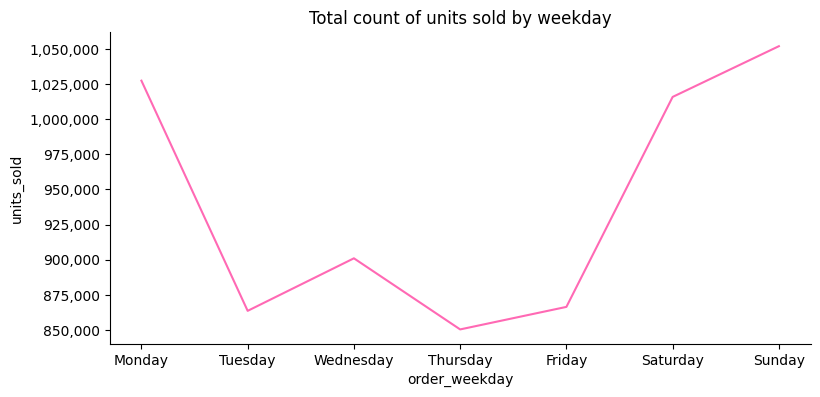

In [ ]:
#building a week statystic by units sold
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_orders_count = pd.pivot_table(sales_df, values = "units_sold", index = "order_weekday", aggfunc="sum").reset_index()

weekday_orders_count['order_weekday'] = pd.Categorical(
    weekday_orders_count['order_weekday'],
    categories=day_order,
    ordered=True)

plot = sns.relplot(x="order_weekday", y="units_sold", kind="line", data= weekday_orders_count, color = "hotpink", height=4, aspect=2)
plot.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.title("Total count of units sold by weekday")


On that plot, we can clearly see the weekly seasonality. From Friday to Monday, more goods are sold than during the rest of the week.

Text(0.5, 1.0, 'Total count of units old by month')

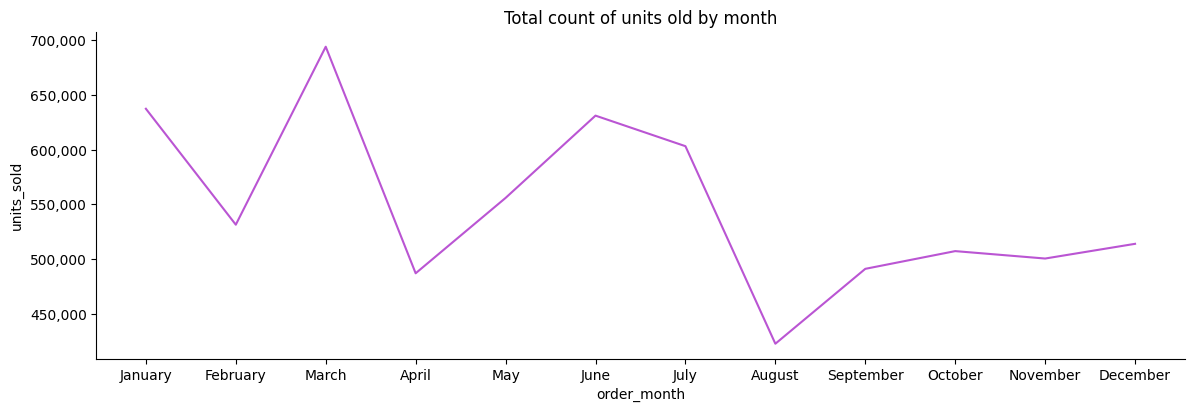

In [ ]:
#building a year statystic by units sold
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

months_order_count = pd.pivot_table(sales_df, values='units_sold', index='order_month', aggfunc='sum').reset_index()

months_order_count['order_month'] = pd.Categorical(
    months_order_count['order_month'],
    categories=month_order,
    ordered=True)

plot = sns.relplot(x="order_month", y="units_sold", kind="line", data= months_order_count, color = "mediumorchid", height=4, aspect=3)
plot.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.title("Total count of units old by month")


/tmp/ipykernel_5456/715613531.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



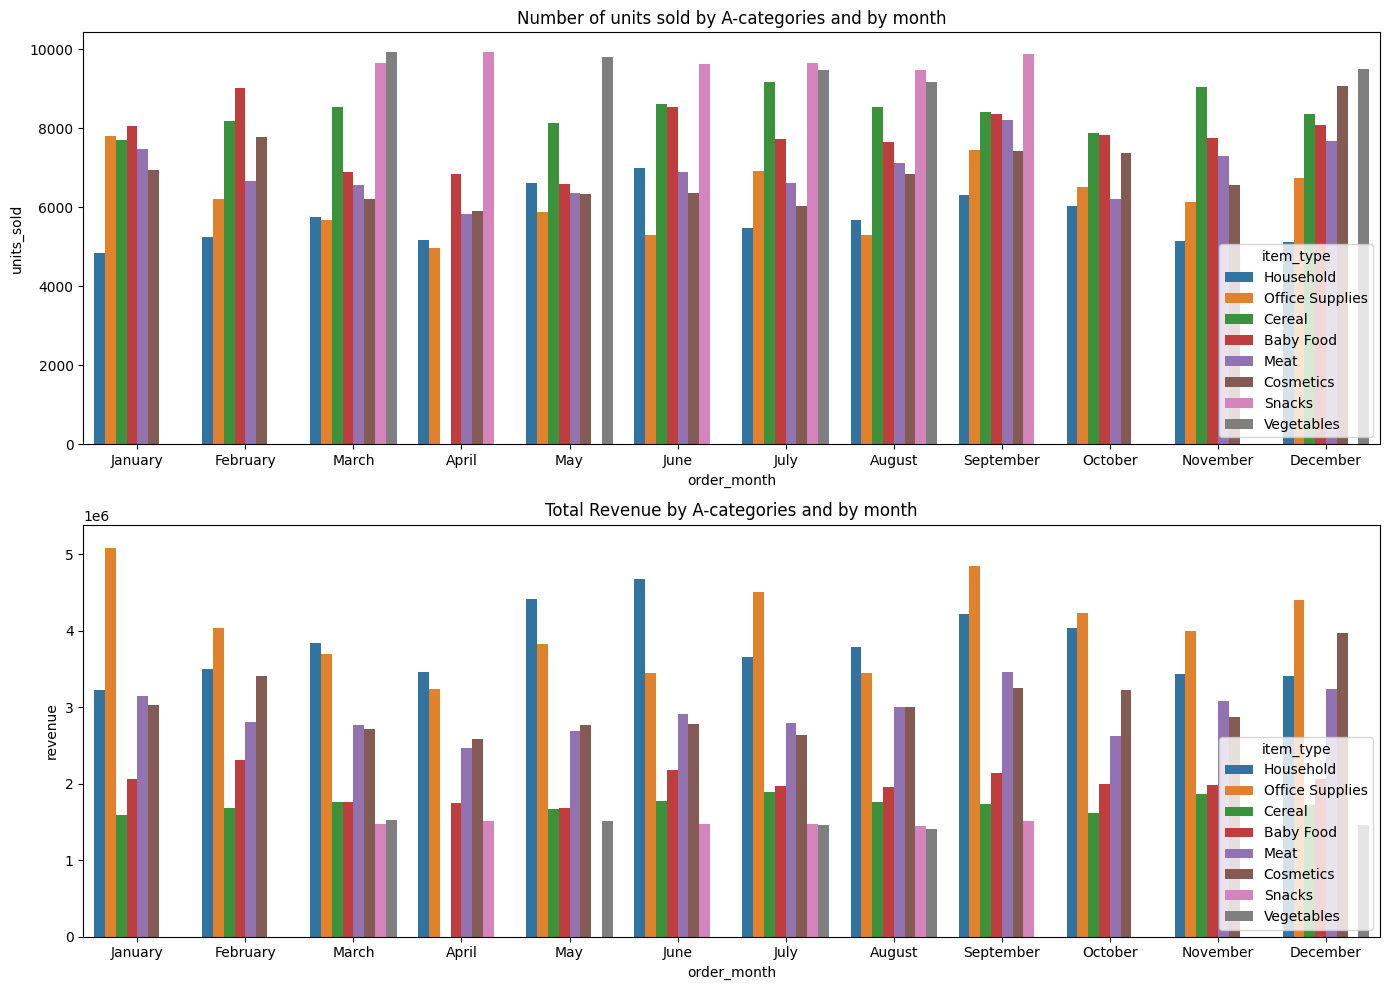

In [ ]:
#counting month seasonality by A-categories
A_categories['order_month'] = pd.Categorical(
   A_categories['order_month'],
    categories=month_order,
    ordered=True)
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

sns.barplot(data=A_categories, x='order_month', y='units_sold', hue='item_type', errorbar=("ci", False), ax=ax[0])
ax[0].set_title("Number of units sold by A-categories and by month")

sns.barplot(data=A_categories, x='order_month', y='revenue', hue='item_type', errorbar=("ci", False), ax=ax[1])
ax[1].set_title("Total Revenue by A-categories and by month")

plt.tight_layout()
plt.show()

On these barcharts we can see the seasonality of sales and revenue by month. \
There is a constant income statistics throughout the year. The most profitable categories are Office Supplies and Household. At the same time, this category has average sales throughout the year. Such income is due to the high price of a unit in these categories.

In turn, I saw an interesting seasonality in the sales of Snacks. They were sold only 5 months a year. But all these 5 months this category was the leader in terms of sales. At the same time, the average profitability of this category is due to low prices for units. The company should pay attention to this category and possibly introduce its sales throughout the entier year to attract more customers to the company

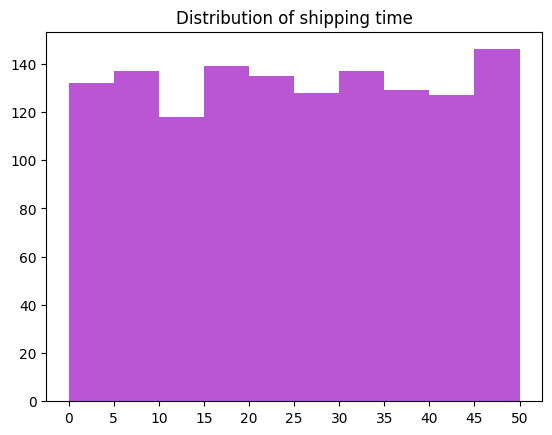

In [ ]:
#calculation of the distribution of order processing and shipping times

plt.hist(sales_df['delivery_time'], bins = 10, color='mediumorchid')
plt.title("Distribution of shipping time")

x_ticks = np.arange(0, sales_df["delivery_time"].max() + 2, 5)
plt.xticks(x_ticks)

plt.show()

The histogram shows that most orders are processed and shipped within 15-50 days

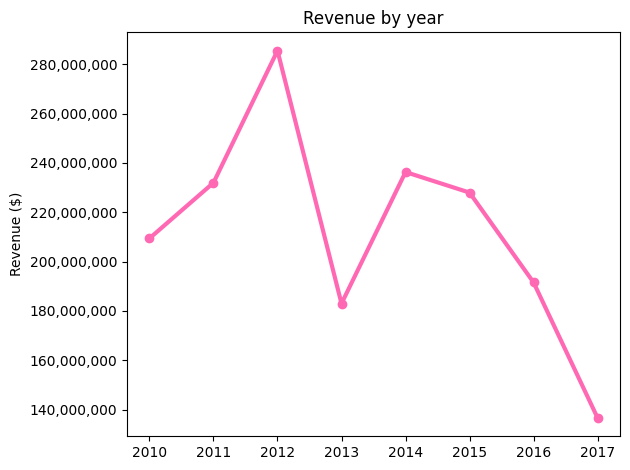

In [ ]:
years_revenue = sales_df.groupby('order_year')['revenue'].sum().reset_index().sort_values(by='order_year')

plt.plot(years_revenue['order_year'],
         years_revenue['revenue'],
         marker = 'o',
         markersize = 6,
         linewidth = 3,
         color='hotpink')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.title("Revenue by year")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

#**Conclution**

###FINANCIAL OVERVIEW
The company's total revenue has been declining for the past three years. The peak revenue of 285 million was reached in 2012.

Total revenue fell by 28.7% compared to the previous year.

###CATEGORIAL INDICATORS
The following product categories bring the most revenue: Office Supplies, Household, Cosmetic.\
The best-selling categories are Office Supplies, Beverages, Fruits.\
The Cosmetics category brings the most profit.\
The least profitable categories are: Personal Care, Beverages, Fruits

###GEOGRAPHICAL INDICATORS
The company sells its products in 45 countries around the world and is present in two regions: Europe and Asia. \
The company receives the most revenue from these countries: Czech Republic, Ukraine, Bosnia and Herzegovina, Macedonia, San Marino.

The least profitable country is Monaco

###SEASONALITY INDICATORS BY DAY AND MONTH
Most orders are placed on Mondays and from Fridays to Sundays. \
From March to September, there is increased demand for categories such as Snacks and Vegetables.\
The average order processing and shipping time is 24 days.\
The most profitable months are May, June and July

###RECOMMENDATIONS AND ACTION PLAN
The company should review and change its pricing strategy for its own products. \
Also, it is necessary to implement the Snacks category sales throughout the year to attract more customers. \
It is necessary to make efforts to advertise and increase sales in the following categories: Office Supplies, Household, Cosmetic. \
It is recomended to reduce the order shipping time and bring all values ​​closer to the average. \

